In [1]:
# Data processing
import pandas as pd
import xarray as xr
import numpy as np
import math

# Plotting 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# Stat and ML
from scipy import stats
from sklearn.model_selection import train_test_split
from tqdm import tqdm 
from statsmodels.tsa.stattools import grangercausalitytests
from scipy.stats import chi2
from sklearn.ensemble import RandomForestRegressor
from scipy.signal import detrend
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score, KFold

# Personal library
from models.granger_pca import GrangerPCA
from models.teleconnection_models import RegressionAnalysis, CompositeAnalysis, CanonicalCorrelationAnalysis, SpatialAveraging
from utils.granger_causality_test import test_granger_causality, test_granger_causality_non_parametric
from utils.xarray_numpy import xr2np, np2D_to_np3D
from utils.utils import generate_past_data, lag_analysis, plot_lag_results, compute_aic_bic, gaussianise_precip
from granger_causality import GrangerCausalityTest
from manova_tests import manova_tests
from utils.plot_weights import *

np.random.seed(1234)

## Loading data

In [2]:
region = 'Europe'
coarsen_factor = 2


if region=='India':
    precip_dataset = xr.open_dataset('/home/homer/Documents/Research/Data/ERA5/pr/era5_total_pr_daily_india.nc').coarsen(latitude=coarsen_factor, longitude=coarsen_factor, boundary='trim').mean()
elif region=='Europe':
    precip_dataset = xr.open_dataset('/home/homer/Documents/Research/Data/ERA5/pr/era5_total_pr_daily_europe_72N_34N_25W_45E.nc').coarsen(latitude=coarsen_factor, longitude=coarsen_factor, boundary='trim').mean()

# Removing anomalies
seasonalities = precip_dataset.groupby('valid_time.month').mean('valid_time')
precip_anomalies = precip_dataset.groupby('valid_time.month') - seasonalities

# Create land mask: land = integer, ocean = NaN
land = regionmask.defined_regions.natural_earth_v5_0_0.land_50
mask = land.mask(precip_anomalies.tp, lon_name='longitude', lat_name='latitude')

anomalies = xr2np(precip_anomalies, mask, var='tp')

# Removing some of the data
if region=='India':
    anomalies = anomalies[:-17, :]

valid_dates = pd.to_datetime(precip_anomalies.valid_time.values)
df = pd.read_csv( "/home/homer/Documents/Research/Data/Climate_Oscillation/norm.daily.nao.cdas.z500.19500101_current.csv")
df["date"] = pd.to_datetime(df[["year", "month", "day"]])
df.set_index("date", inplace=True)

df_selected = df.loc[df.index.intersection(valid_dates)]

oscillation = df_selected['nao_index_cdas'].fillna(0).to_numpy()


/tmp/ipykernel_26371/2313587839.py:15: UserWarning: `land_50` of `natural_earth_v4_1_0` and `natural_earth_v5_0_0` does not quite extend to 90°S - it's recommended to use `natural_earth_v5_1_2` instead. See https://github.com/regionmask/regionmask/issues/487
  land = regionmask.defined_regions.natural_earth_v5_0_0.land_50
/home/homer/anaconda3/envs/gpca/lib/python3.9/site-packages/regionmask/core/mask.py:179: FutureWarning: Passing 'lon_name' and 'lat_name' was deprecated in v0.10.0. Please pass the coordinates directly, e.g., `mask*(ds[lon_name], ds[lat_name])`.
  warnings.warn(


## Data preprocessing

In [3]:
# Data splitting
train_ratio = 0.6
    
n = len(anomalies)
train_size = int(n * train_ratio)

anomalies_train = anomalies[:train_size, :]
anomalies_test  = anomalies[train_size:, :]

oscillation_train = oscillation[:train_size]
oscillation_test  = oscillation[train_size:]

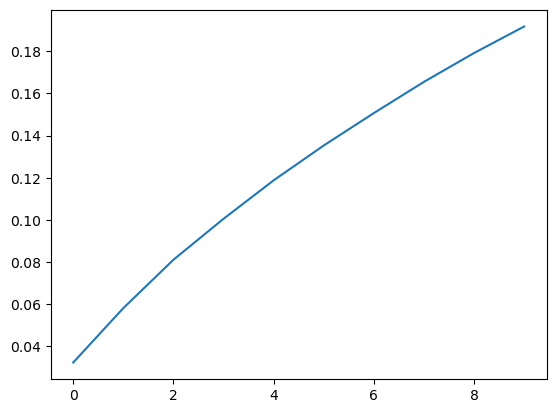

In [4]:
# Principal Component Analysis
ncp = 10
    
pca = PCA(n_components=ncp)
pca.fit(anomalies_train)
plt.plot(np.cumsum(pca.explained_variance_ratio_))


anomalies_pca_train = pca.transform(anomalies_train)
anomalies_pca_test = pca.transform(anomalies_test)

anomalies_pca = pca.transform(anomalies)

## Fitting Granger PCA
* Seting maxlag to *None* to that optimal lag is selected to maximise the *lag_criterion* score of a model predicting $Y$ from $X$ and $Y$'s pasts.
* Different algorithms are available: *diff_ratio* maximise the F-statistic, *ratio* maximise the likelihood ratio and *difference* maximise the RSS difference

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:09<00:00,  1.11it/s]


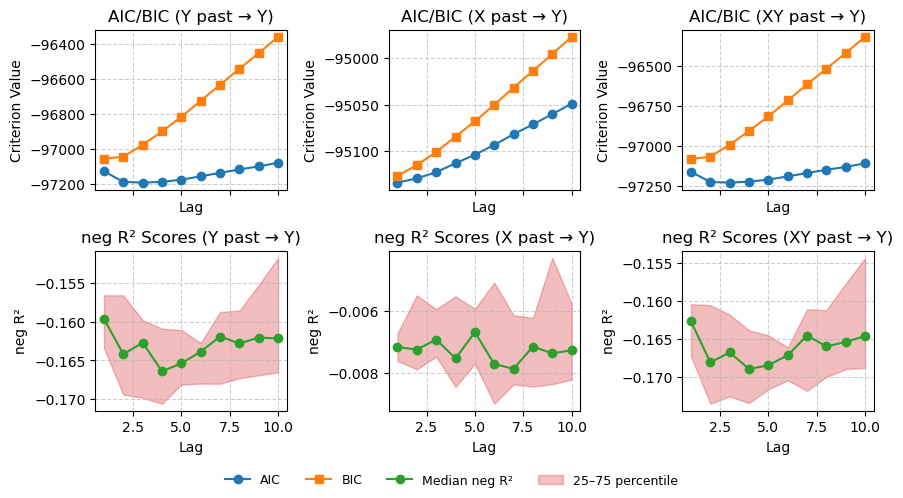

       eigs
0  0.040784


In [5]:
lag = 3
alphas=np.logspace(-2, 5, 100)
gpca = GrangerPCA(maxlag=None, maxlags=range(1, 11), method='diff_ratio', lag_criterion='BIC' )
gpca.fit(oscillation_train[:, None], anomalies_pca_train, plot_lag_analysis=True, verbose=True)

In [6]:
cp_test_gpca = gpca.transform(anomalies_pca_test)

## Fitting other algorithms
* Using the same optimal time lag found during Granger PCA analysis 

In [7]:
ca = CompositeAnalysis(maxlag=gpca.maxlag)
ca.fit(oscillation_train[:, None], anomalies_pca_train)
cp_test_ca = ca.transform(anomalies_pca_test, type='PosNeg')

ra = RegressionAnalysis(maxlag=gpca.maxlag)
ra.fit(oscillation_train[:, None], anomalies_pca_train)
cp_test_ra = ra.transform(anomalies_pca_test)

cca = CanonicalCorrelationAnalysis(maxlag=gpca.maxlag, n_components=1)
cca.fit(oscillation_train[:, None], anomalies_pca_train)
cp_test_cca = cca.transform(anomalies_pca_test)

sa = SpatialAveraging()
sa.fit(oscillation_train[:, None], anomalies_train)
cp_test_sa = sa.transform(anomalies_test)


## Testing Granger causality 
* We test Granger causality between the extracted component $\tilde{Y}$ and the climate oscillation $X$

In [8]:
results_gpca = test_granger_causality(oscillation_test[:, None], cp_test_gpca[:, 0], maxlag=[gpca.maxlag])
results_ra = test_granger_causality(oscillation_test[:, None], cp_test_ra, maxlag=[gpca.maxlag])
results_ca = test_granger_causality(oscillation_test[:, None], cp_test_ca, maxlag=[gpca.maxlag])
results_cca = test_granger_causality(oscillation_test[:, None], cp_test_cca, maxlag=[gpca.maxlag])
results_sa = test_granger_causality(oscillation_test[:, None], cp_test_sa, maxlag=[gpca.maxlag])

### Results

In [9]:
# Combine results 
combined = pd.concat(
    [
        results_gpca[results_gpca['lag'] == gpca.maxlag],
        results_cca[results_cca['lag'] == gpca.maxlag],
        results_ca[results_ca['lag'] == gpca.maxlag],
        results_ra[results_ra['lag'] == gpca.maxlag],
        results_sa[results_sa['lag'] == gpca.maxlag]
    ],
    keys=['GPCA', 'CCA', 'Composites', 'Regression', 'Spatial Average']
).reset_index(level=0).rename(columns={'level_0': 'Method'})

# Export to LaTeX
latex_table = combined[['F_statistic', 'p_value']].to_latex(
    index=True,         
    caption=f"Comparison of Results by Method at lag = {gpca.maxlag}",
    label="tab:results_by_method",
    float_format="%.6f",  
    escape=True         
)

# Save to file
with open(f"tables/teleconnection_pvalues_precipitation_{region}_coarsen-{coarsen_factor}_lag-{gpca.maxlag}.tex", "w") as f:
    f.write(latex_table)


In [10]:
combined

,Method,lag,Y_column,F_statistic,df1,df2,p_value,F_critical,alpha_used,interpretation
0,GPCA,1,1,184.222067,1,6572,2.089431e-41,3.842874,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=1)
0,CCA,1,1,155.271462,1,6572,3.048328e-35,3.842874,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=1)
0,Composites,1,1,133.568069,1,6572,1.340027e-30,3.842874,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=1)
0,Regression,1,1,131.793845,1,6572,3.217816e-30,3.842874,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=1)
0,Spatial Average,1,1,13.861952,1,6572,1.983870e-04,3.842874,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=1)


In [11]:
idx = 0 # Which GPC

weights_gpca = np2D_to_np3D(normalise((gpca.vects_[:, idx] @ pca.components_))[None, :], mask)[0, :, :]
weights_ra = np2D_to_np3D(normalise((ra.lr.coef_.T @ pca.components_)[0, :])[None, :], mask)[0, :, :]
weights_ca =np2D_to_np3D( normalise(ca.composites['PosNeg'].to_numpy() @ pca.components_)[None, :], mask)[0, :, :]
weights_cca = np2D_to_np3D(normalise((cca.cca.y_rotations_.T @ pca.components_)[0, :])[None, :], mask)[0, :, :]
weights_sa = np2D_to_np3D(sa.weights_[None, :], mask)[0, :, :]
    
weights = {'GPCA':{'weights':weights_gpca, 'p-value':results_gpca[results_gpca['lag']==gpca.maxlag]['p_value']}, 
            'Regression':{'weights':weights_ra, 'p-value':results_ra[results_ra['lag']==gpca.maxlag]['p_value']},
            'Composites':{'weights':weights_ca, 'p-value':results_ca[results_ca['lag']==gpca.maxlag]['p_value']},
            'CCA':{'weights':weights_cca, 'p-value':results_cca[results_cca['lag']==gpca.maxlag]['p_value']}
            # 'Average':{'weights':weights_sa, 'p-value':results_sa[results_sa['lag']==gpca.maxlag]['p_value_parametric']}
        }

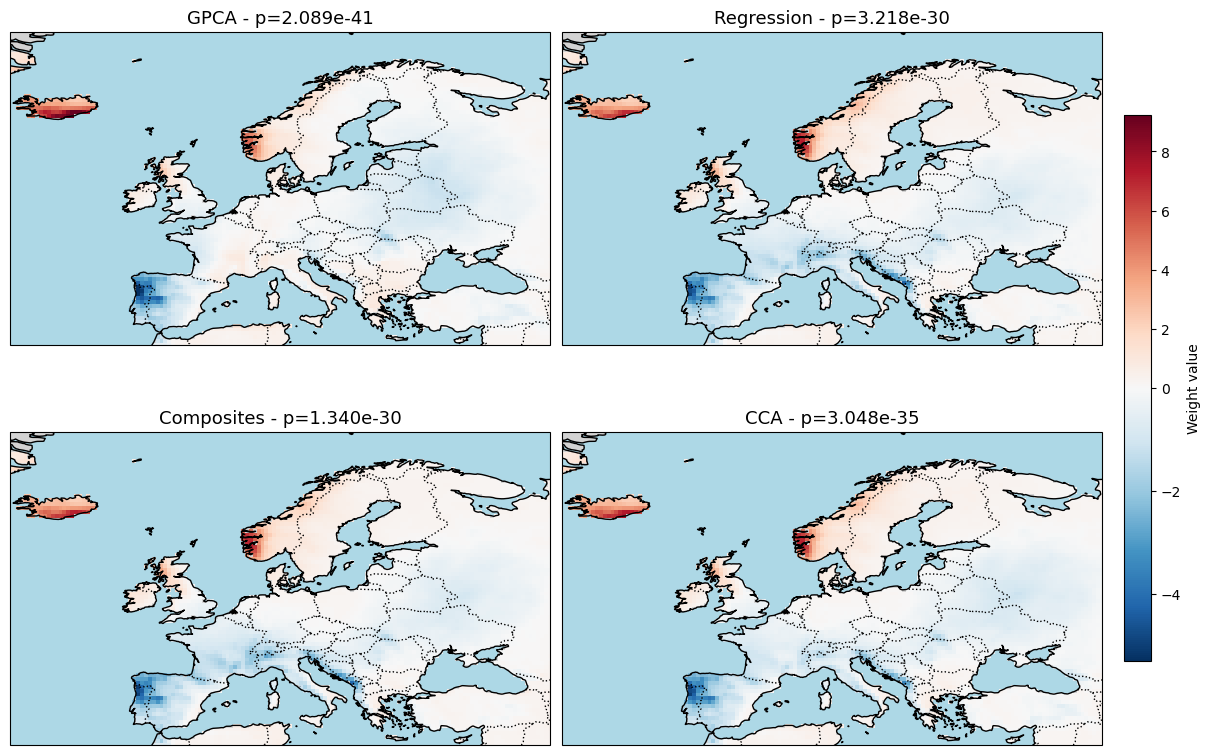

In [12]:
path = f'figures/teleconnection_weights_precipitation_{region}_coarsen-{coarsen_factor}_lag-{gpca.maxlag}.pdf'

lon=precip_anomalies['tp'].longitude.values
lat=precip_anomalies['tp'].latitude.values
plot_weight_maps(weights, 'Precipitation', lon, lat, extent=None, save_path=path)